In [ ]:
# Langkah 1: Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [ ]:
# Langkah 2: Membaca dan eksplorasi dataset
# Gantilah 'dataset.csv' dengan path ke file dataset Anda
df = pd.read_csv('data_finish.csv', delimiter=',')

# Melihat 5 baris pertama dataset
print(df.head())

# Informasi mengenai dataset
print(df.info())


         date    Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg  \
0  2016-01-01  26.0  34.8  28.6    81.0   NaN  5.8   5.0  280.0     2.0   
1  2016-01-02  25.6  33.2  27.0    88.0   1.6  8.7   4.0  290.0     2.0   
2  2016-01-03  24.4  34.9  28.1    80.0  33.8  5.4   4.0  280.0     2.0   
3  2016-01-04  24.8  33.6  29.2    81.0   NaN  6.6   3.0  200.0     1.0   
4  2016-01-05  25.8  33.6  26.7    91.0   NaN  3.2   3.0  180.0     1.0   

  ddd_car  station_id                station_name      region_name  flood  
0      S        96733  Stasiun Klimatologi Banten  Jakarta Selatan      0  
1      W        96733  Stasiun Klimatologi Banten  Jakarta Selatan      1  
2      SW       96733  Stasiun Klimatologi Banten  Jakarta Selatan      1  
3      S        96733  Stasiun Klimatologi Banten  Jakarta Selatan      0  
4      S        96733  Stasiun Klimatologi Banten  Jakarta Selatan      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6308 entries, 0 to 6307
Data columns (total

In [ ]:
df.drop('date', axis=1, inplace=True)

In [ ]:
# Mengecek nilai kosong dalam dataset
print(df.isnull().sum())

Tn              0
Tx              0
Tavg            0
RH_avg          0
RR              0
ss              0
ff_x            0
ddd_x           0
ff_avg          0
ddd_car         0
station_id      0
station_name    0
region_name     0
flood           0
dtype: int64


In [ ]:
# Langkah 3: Preprocessing data
# Mengencode fitur kategorikal
le_ddd_car = LabelEncoder()
df['ddd_car'] = le_ddd_car.fit_transform(df['ddd_car'])

le_station = LabelEncoder()
df['station_name'] = le_station.fit_transform(df['station_name'])

le_region = LabelEncoder()
df['region_name'] = le_region.fit_transform(df['region_name'])

In [ ]:
# Memisahkan kolom numerik dan kategorikal
numerical_cols = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ddd_x', 'ff_avg']
categorical_cols = ['station_name', 'region_name', 'ddd_car']

In [ ]:
# Langkah 4: Mengisi missing values menggunakan KNNImputer
# Inisialisasi KNNImputer
imputer = KNNImputer(n_neighbors=5)

In [ ]:
# Hanya menggunakan kolom numerik untuk imputer
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

In [ ]:
# Mengecek kembali nilai kosong dalam dataset
print(df.isnull().sum())

Tn              0
Tx              0
Tavg            0
RH_avg          0
RR              0
ss              0
ff_x            0
ddd_x           0
ff_avg          0
ddd_car         0
station_id      0
station_name    0
region_name     0
flood           0
dtype: int64


In [ ]:
# Langkah 5: Memisahkan dataset menjadi data latih dan data uji
# Menentukan fitur dan target
X = df.drop(columns=['flood', 'station_id'])
y = df['flood']

In [ ]:
# Membagi dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Langkah 6: Melatih model Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Definisikan grid parameter yang akan diuji
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=1,
                           n_jobs=-1)

# Lakukan grid search pada data latih
grid_search.fit(X_train, y_train)

# Cetak parameter terbaik yang ditemukan
print("Parameter terbaik:", grid_search.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Parameter terbaik: {'max_depth': 10, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}


In [ ]:
# Prediksi dengan model terbaik
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluasi model terbaik
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1748
           1       0.42      0.03      0.06       145

    accuracy                           0.92      1893
   macro avg       0.67      0.52      0.51      1893
weighted avg       0.89      0.92      0.89      1893

Accuracy: 0.9223454833597464


In [ ]:
# Langkah 7: Evaluasi model
y_pred = model.predict(X_test)

In [ ]:
# Evaluasi dengan confusion matrix dan classification report
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1748
           1       0.50      0.06      0.11       145

    accuracy                           0.92      1893
   macro avg       0.71      0.53      0.54      1893
weighted avg       0.89      0.92      0.89      1893

Accuracy: 0.9234020073956682


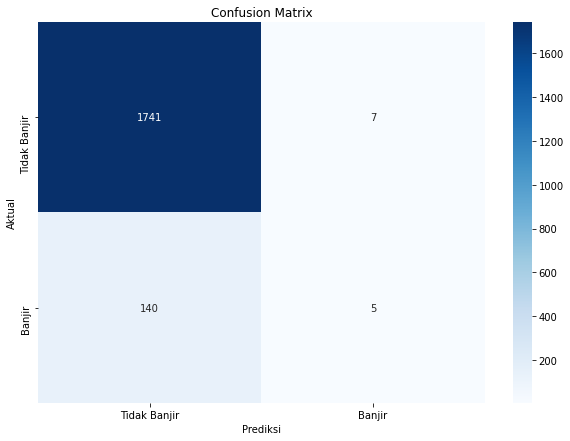

In [ ]:
# Langkah 8: Visualisasi confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Banjir', 'Banjir'], yticklabels=['Tidak Banjir', 'Banjir'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()